# ZeroS vs Softmax Attention vs MHLA — GPU Comparison

| Model | Complexity | Description |
|-------|------------|-------------|
| **Softmax** | O(L²) | Standard causal multi-head attention |
| **MHLA** | O(L²) | Multi-Head Latent Attention — shared low-rank KV compression (DeepSeek-V2 style) |
| **ZeroS** | O(L·d²) | Zero-Sum Linear Attention — reweighted softmax decomposition + learned gates |

**Dataset:** TinyShakespeare (char-level, ~1M tokens)  
**Task:** Causal language modeling


## 0. Setup

In [1]:
import os, math, time, gc, urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from types import SimpleNamespace
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU : NVIDIA GeForce RTX 3060
VRAM: 12.5 GB


## 1. Dataset

In [2]:
URL       = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_FILE = "input.txt"

if not os.path.exists(DATA_FILE):
    urllib.request.urlretrieve(URL, DATA_FILE)

with open(DATA_FILE, "r") as f:
    text = f.read()

chars      = sorted(set(text))
vocab_size = len(chars)
stoi       = {c: i for i, c in enumerate(chars)}
itos       = {i: c for i, c in enumerate(chars)}
encode     = lambda s:  [stoi[c] for c in s]
decode     = lambda xs: "".join(itos[i] for i in xs)

data    = torch.tensor(encode(text), dtype=torch.long)
n_split = int(0.9 * len(data))
train_data, val_data = data[:n_split], data[n_split:]
print(f"Vocab: {vocab_size} | Train tokens: {len(train_data):,} | Val tokens: {len(val_data):,}")

Vocab: 65 | Train tokens: 1,003,854 | Val tokens: 111,540


In [3]:
BLOCK_SIZE = 256
BATCH_SIZE = 32

class CharDataset(Dataset):
    def __init__(self, data, block_size):
        self.data, self.bs = data, block_size
    def __len__(self):
        return len(self.data) - self.bs
    def __getitem__(self, i):
        return self.data[i : i + self.bs], self.data[i + 1 : i + self.bs + 1]

_kw = dict(batch_size=BATCH_SIZE, drop_last=True,
           num_workers=0, pin_memory=(device.type == "cuda"))
train_loader = DataLoader(CharDataset(train_data, BLOCK_SIZE), shuffle=True,  **_kw)
val_loader   = DataLoader(CharDataset(val_data,   BLOCK_SIZE), shuffle=False, **_kw)

cfg = SimpleNamespace(
    n_embd=128, n_head=4, n_layer=4,
    bias=True, dropout=0.1, block_size=BLOCK_SIZE,
    is_causal=True, vocab_size=vocab_size,
    use_norm=True, use_associative=True, is_first_layer=False,
)
print(f"Config: D={cfg.n_embd}, H={cfg.n_head}, layers={cfg.n_layer}, block={cfg.block_size}, vocab={cfg.vocab_size}")

Config: D=128, H=4, layers=4, block=256, vocab=65


## 2. Attention Implementations

### 2.1 Softmax Attention
Стандартный механизм. Сложность O(L²) по памяти и FLOPs.

In [4]:
class SoftmaxAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.H = config.n_head
        self.d = config.n_embd // config.n_head
        self.D = config.n_embd
        self.qkv      = nn.Linear(self.D, 3 * self.D, bias=config.bias)
        self.out_proj = nn.Linear(self.D, self.D,     bias=config.bias)
        self.drop     = nn.Dropout(config.dropout)
        self.register_buffer(
            "attn_mask",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, L, D = x.shape
        q, k, v = self.qkv(x).split(self.D, dim=-1)
        split = lambda t: t.view(B, L, self.H, self.d).transpose(1, 2)
        q, k, v = split(q), split(k), split(v)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d)
        att = att.masked_fill(self.attn_mask[:, :, :L, :L] == 0, float("-inf"))
        att = self.drop(F.softmax(att, dim=-1))
        out = (att @ v).transpose(1, 2).contiguous().view(B, L, D)
        return self.drop(self.out_proj(out))

### 2.2 MHLA — Multi-Head Latent Attention
Q и KV пропускаются через общую низкоранговую проекцию (d_c = D/4).  
KV-cache при инференсе: O(L·d_c) вместо O(L·2D) — главный выигрыш DeepSeek-V2.  
Сложность вычислений при обучении — как у Softmax: O(L²).

In [5]:
class MHLA(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.H   = config.n_head
        self.d   = config.n_embd // config.n_head
        self.D   = config.n_embd
        self.d_c = getattr(config, "d_c", config.n_embd // 4)

        self.W_dq    = nn.Linear(self.D,   self.d_c, bias=False)
        self.W_uq    = nn.Linear(self.d_c, self.D,   bias=config.bias)
        self.W_dkv   = nn.Linear(self.D,   self.d_c, bias=False)
        self.W_uk    = nn.Linear(self.d_c, self.D,   bias=False)
        self.W_uv    = nn.Linear(self.d_c, self.D,   bias=False)
        self.out_proj = nn.Linear(self.D,  self.D,   bias=config.bias)
        self.drop     = nn.Dropout(config.dropout)
        self.register_buffer(
            "attn_mask",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, L, D = x.shape

        q   = self.W_uq(self.W_dq(x)).view(B, L, self.H, self.d).transpose(1, 2)

        c_kv = self.W_dkv(x)
        k    = self.W_uk(c_kv).view(B, L, self.H, self.d).transpose(1, 2)
        v    = self.W_uv(c_kv).view(B, L, self.H, self.d).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d)
        att = att.masked_fill(self.attn_mask[:, :, :L, :L] == 0, float("-inf"))
        att = self.drop(F.softmax(att, dim=-1))
        out = (att @ v).transpose(1, 2).contiguous().view(B, L, D)
        return self.drop(self.out_proj(out))

### 2.3 ZeroS — Zero-Sum Linear Attention
Разлагаем softmax-веса на нулевой / первый / высший порядки:  
- нулевой порядок (равномерное усреднение) — явно удаляется  
- первый порядок масштабируется через σ¹  
- высший порядок масштабируется через σʰ  

RoPE на Q, K; per-head LayerNorm на выходе; девиационные логиты s_i.  
Сложность O(L·d²).

In [6]:
def _rotate_half(x):
    a, b = x.chunk(2, dim=-1)
    return torch.cat((-b, a), dim=-1)

def _apply_rope(x, cos, sin):
    return x * cos + _rotate_half(x) * sin

def _get_rope(L, d, base=10000.0, device=None):
    assert d % 2 == 0
    inv = 1.0 / (base ** (torch.arange(0, d, 2, device=device).float() / d))
    s   = torch.arange(L, device=device, dtype=torch.float32)[:, None] * inv[None]
    cos = torch.cat([torch.cos(s), torch.cos(s)], dim=-1)[None, :, None, :]
    sin = torch.cat([torch.sin(s), torch.sin(s)], dim=-1)[None, :, None, :]
    return cos, sin

@torch.no_grad()
def _causal_mask(L, device):
    return torch.tril(torch.ones(L, L, device=device)).view(1, 1, L, L).bool()


def compute_o(q, s_i, k, v, gate, mask=None, causal=True,
              associative=True, is_first_layer=False, eps=1e-12):
    B, L, H, d = q.shape

    if associative:
        exp_s = torch.exp(s_i - s_i.max(1, keepdim=True)[0].detach())
        t = (torch.arange(1, L + 1, device=q.device, dtype=q.dtype).view(1, L, 1, 1)
             if causal else float(L))

        E  = exp_s.cumsum(1) if causal else exp_s.sum(1, keepdim=True).expand(-1, L, -1, -1)
        kv = torch.einsum("blhd,blhe->blhde", k, v)

        F_ = ((exp_s.unsqueeze(-1) * kv).cumsum(1) if causal
              else (exp_s.unsqueeze(-1) * kv).sum(1, keepdim=True).expand(-1, L, -1, -1, -1))
        H_ = (kv.cumsum(1) if causal
              else kv.sum(1, keepdim=True).expand(-1, L, -1, -1, -1))

        # masked softmax always sums to 1 (st_sum == 1), so f1 = s_soft/t - 1/t^2 and
        # r = a*f1 + b*fr collapses to a combo of exp(s_i)/E (-> F_) and constants (-> H_);
        # no separate s_i-linear term survives, so G_/P from the naive expansion drop out
        a     = torch.sigmoid(gate[..., [0]])
        b     = torch.sigmoid(gate[..., [1]])
        alpha = ((a - b) / t + b) / (E + eps)
        gamma = -((a - b) / t ** 2 + b / t)
        core  = alpha.unsqueeze(-1) * F_ + gamma.unsqueeze(-1) * H_
        out   = torch.einsum("blhd,blhde->blhe", q, core)

        if is_first_layer:
            s0  = torch.tanh(gate[..., [2]])
            out = out + s0 * torch.einsum("blhd,blhde->blhe", q / t, H_)
        return out

    if causal and mask is None:
        mask = _causal_mask(L, q.device)

    cos_th = torch.einsum("blhd,bihd->bhli", q, k)
    if mask is not None and causal:
        cos_th = cos_th.masked_fill(~mask, 0)

    si_exp = s_i.permute(0, 2, 3, 1).expand(-1, -1, L, -1)
    si_exp = si_exp.masked_fill(~mask, float("-inf")) if (causal and mask is not None) else si_exp
    s_soft = F.softmax(si_exp, dim=-1)
    s_tril = s_soft.masked_fill(~mask, 0) if (causal and mask is not None) else s_soft
    st_sum = s_tril.sum(-1, keepdim=True)

    t  = (torch.arange(1, L + 1, device=q.device, dtype=q.dtype).view(1, 1, L, 1)
          if causal else int(L))
    f0 = 1.0 / t
    f1 = (s_tril / t) - (st_sum / t ** 2)
    fr = s_soft - f0 - f1

    if is_first_layer:
        r = (torch.sigmoid(gate[..., [0]]).transpose(1, 2) * f1
           + torch.sigmoid(gate[..., [1]]).transpose(1, 2) * fr
           + torch.tanh(gate[..., [2]]).transpose(1, 2) * f0)
    else:
        r = (torch.sigmoid(gate[..., [0]]).transpose(1, 2) * f1
           + torch.sigmoid(gate[..., [1]]).transpose(1, 2) * fr)

    w = r * cos_th
    if mask is not None and causal:
        w = w.masked_fill(~mask, 0)
    return torch.einsum("bhli,bihd->blhd", w, v)


class ZeroSAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.D = config.n_embd
        self.H = config.n_head
        self.d = self.D // self.H

        self.q        = nn.Linear(self.D, self.D,     bias=config.bias)
        self.k        = nn.Linear(self.D, self.D,     bias=config.bias)
        self.v        = nn.Linear(self.D, self.D,     bias=config.bias)
        self.u        = nn.Linear(self.D, self.D,     bias=config.bias)
        self.gate     = nn.Linear(self.D, 3 * self.H, bias=config.bias)
        self.out_proj = nn.Linear(self.D, self.D,     bias=config.bias)
        self.dropout  = nn.Dropout(config.dropout)

        cos, sin = _get_rope(config.block_size, self.d)
        self.register_buffer("cos", cos)
        self.register_buffer("sin", sin)
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size).bool()
        )

        self.norm         = nn.LayerNorm(self.d, eps=1e-5, elementwise_affine=False)
        self.prior_mu     = nn.Parameter(torch.zeros(1, 1, self.H, self.d))
        self.prior_log_t  = nn.Parameter(torch.zeros(1, 1, self.H, 1))

        self.is_first  = getattr(config, "is_first_layer",  False)
        self.is_causal = getattr(config, "is_causal",       True)
        self.use_norm  = getattr(config, "use_norm",        True)
        self.use_assoc = getattr(config, "use_associative", True)

    def forward(self, x):
        B, L, D = x.shape
        q    = self.q(x).view(B, L, self.H, self.d)
        k    = self.k(x).view(B, L, self.H, self.d)
        v    = self.v(x).view(B, L, self.H, self.d)
        u    = self.u(x).view(B, L, self.H, self.d)
        gate = self.gate(x).view(B, L, self.H, 3)
        s_i  = self._logit(u)
        q    = _apply_rope(q, self.cos[:, :L], self.sin[:, :L])
        k    = _apply_rope(k, self.cos[:, :L], self.sin[:, :L])
        q    = F.normalize(q, p=2, dim=-1)
        k    = F.normalize(k, p=2, dim=-1)
        out  = compute_o(q, s_i, k, v, gate=gate,
                         mask=self.bias[:, :, :L, :L],
                         causal=self.is_causal,
                         associative=self.use_assoc,
                         is_first_layer=self.is_first)
        if self.use_norm:
            out = self.norm(out)
        return self.dropout(self.out_proj(out.reshape(B, L, D)))

    def _logit(self, u):
        _, L, _, _ = u.shape
        t   = torch.arange(1, L + 1, device=u.device, dtype=u.dtype).view(1, L, 1, 1)
        tau = torch.exp(self.prior_log_t.clip(-50, 30))
        u_s = u.cumsum(1) if self.is_causal else u.sum(1, keepdim=True)
        mu  = (tau * self.prior_mu + u_s) / (tau + t)
        return -(u * mu).sum(-1, keepdim=True) / math.sqrt(self.d)

## 3. Language Model
Минимальный Transformer (D=128, H=4, 4 слоя) поверх каждого attention.

In [7]:
class Block(nn.Module):
    def __init__(self, config, attn_cls):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.n_embd)
        self.ln2  = nn.LayerNorm(config.n_embd)
        self.attn = attn_cls(config)
        self.ff   = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class LM(nn.Module):
    def __init__(self, config, attn_cls):
        super().__init__()
        self.config  = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.drop    = nn.Dropout(config.dropout)
        self.blocks  = nn.ModuleList([Block(config, attn_cls) for _ in range(config.n_layer)])
        self.ln_f    = nn.LayerNorm(config.n_embd)
        self.head    = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if hasattr(m, "bias") and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None):
        B, L = idx.shape
        pos    = torch.arange(L, device=idx.device)
        x      = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for blk in self.blocks:
            x = blk(x)
        logits = self.head(self.ln_f(x))
        loss   = (F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
                  if targets is not None else None)
        return logits, loss


def nparams(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

for _name, _cls in [("Softmax", SoftmaxAttention), ("MHLA", MHLA), ("ZeroS", ZeroSAttention)]:
    _m = LM(cfg, _cls)
    print(f"{_name:<10} params: {nparams(_m):>10,}")
    del _m

Softmax    params:    842,752


MHLA       params:    727,040


ZeroS      params:    915,520


## 4. Speed & Memory Benchmark
Замер median forward / forward+backward времени и пиковой GPU-памяти  
для разных длин последовательности. B=2, D=128, H=4.

In [8]:
SEQ_LENS    = [64, 128, 256, 512, 1024, 2048]
BENCH_BATCH = 2
COLORS      = {"Softmax": "#e74c3c", "MHLA": "#27ae60", "ZeroS": "#2980b9"}
MARKS       = {"Softmax": "o",       "MHLA": "s",       "ZeroS": "^"}


def benchmark(attn_cls, seq_lens, n_warmup=3, n_runs=10):
    fwd_ms, total_ms, mem_mb = [], [], []
    for L in seq_lens:
        bs   = max(L, cfg.block_size)
        bcfg = SimpleNamespace(**vars(cfg)); bcfg.block_size = bs
        model = attn_cls(bcfg).to(device).train()
        x = torch.randn(BENCH_BATCH, L, cfg.n_embd, device=device, requires_grad=True)

        for _ in range(n_warmup):
            out = model(x)
            out.sum().backward()
            model.zero_grad(set_to_none=True)
            x = x.detach().requires_grad_(True)

        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        ft, tt = [], []

        for _ in range(n_runs):
            torch.cuda.synchronize(); t0 = time.perf_counter()
            out = model(x)
            torch.cuda.synchronize(); t1 = time.perf_counter()
            out.sum().backward()
            torch.cuda.synchronize(); t2 = time.perf_counter()
            ft.append((t1 - t0) * 1e3)
            tt.append((t2 - t0) * 1e3)
            model.zero_grad(set_to_none=True)
            x = x.detach().requires_grad_(True)

        fwd_ms.append(float(np.median(ft)))
        total_ms.append(float(np.median(tt)))
        mem_mb.append(torch.cuda.max_memory_allocated() / 1e6)
        print(f"  L={L:5d} | fwd {fwd_ms[-1]:7.2f} ms | fwd+bwd {total_ms[-1]:7.2f} ms | mem {mem_mb[-1]:8.1f} MB")
        del model
        gc.collect()
        torch.cuda.empty_cache()

    return {"fwd": fwd_ms, "total": total_ms, "mem": mem_mb}

In [9]:
bench = {}
for _name, _cls in [("Softmax", SoftmaxAttention), ("MHLA", MHLA), ("ZeroS", ZeroSAttention)]:
    print(f"\n=== {_name} ===")
    bench[_name] = benchmark(_cls, SEQ_LENS)
print("\nDone.")


=== Softmax ===


  L=   64 | fwd    0.72 ms | fwd+bwd    1.87 ms | mem     19.7 MB
  L=  128 | fwd    0.53 ms | fwd+bwd    2.18 ms | mem     21.5 MB


  L=  256 | fwd    0.71 ms | fwd+bwd    2.28 ms | mem     28.4 MB
  L=  512 | fwd    0.55 ms | fwd+bwd    1.55 ms | mem     55.9 MB


  L= 1024 | fwd    1.62 ms | fwd+bwd    4.34 ms | mem    163.1 MB


  L= 2048 | fwd    5.49 ms | fwd+bwd   13.93 ms | mem    586.7 MB

=== MHLA ===
  L=   64 | fwd    0.58 ms | fwd+bwd    2.52 ms | mem     19.6 MB


...

  L= 2048 | fwd    5.56 ms | fwd+bwd   13.89 ms | mem    587.7 MB

=== ZeroS ===


  L=   64 | fwd    2.95 ms | fwd+bwd    6.43 ms | mem     31.9 MB
  L=  128 | fwd    2.06 ms | fwd+bwd    7.55 ms | mem     45.2 MB


  L=  256 | fwd    1.98 ms | fwd+bwd    7.49 ms | mem     71.9 MB
  L=  512 | fwd    2.99 ms | fwd+bwd    6.41 ms | mem    125.5 MB


  L= 1024 | fwd    3.19 ms | fwd+bwd    9.34 ms | mem    233.1 MB


  L= 2048 | fwd    5.54 ms | fwd+bwd   17.36 ms | mem    450.0 MB

Done.


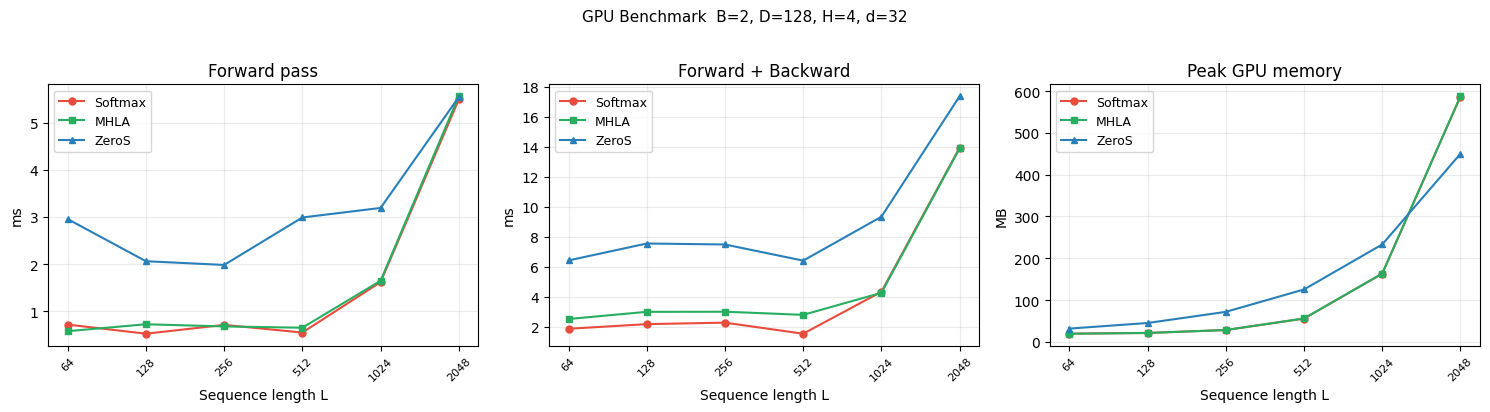

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"GPU Benchmark  B={BENCH_BATCH}, D={cfg.n_embd}, H={cfg.n_head}, d={cfg.n_embd // cfg.n_head}",
             fontsize=11, y=1.02)

for _name, _res in bench.items():
    _kw = dict(color=COLORS[_name], marker=MARKS[_name], linewidth=1.5, markersize=5, label=_name)
    axes[0].plot(SEQ_LENS, _res["fwd"],   **_kw)
    axes[1].plot(SEQ_LENS, _res["total"], **_kw)
    axes[2].plot(SEQ_LENS, _res["mem"],   **_kw)

for ax, title, ylab in zip(axes,
        ["Forward pass", "Forward + Backward", "Peak GPU memory"],
        ["ms", "ms", "MB"]):
    ax.set_title(title)
    ax.set_xlabel("Sequence length L")
    ax.set_ylabel(ylab)
    ax.set_xscale("log", base=2)
    ax.set_xticks(SEQ_LENS)
    ax.set_xticklabels(SEQ_LENS, rotation=45, fontsize=8)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Training Comparison
Одинаковые seed=42, AdamW lr=3e-4, 3000 шагов, оценка каждые 250 шагов.

In [11]:
TRAIN_STEPS = 3000
EVAL_EVERY  = 250
LR          = 3e-4


def train_model(attn_cls, name, seed=42):
    torch.manual_seed(seed)
    model = LM(cfg, attn_cls).to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR,
                               weight_decay=0.1, betas=(0.9, 0.95))

    steps, tr_hist, vl_hist = [], [], []
    loader       = iter(train_loader)
    running_loss = 0.0
    model.train()

    for step in range(1, TRAIN_STEPS + 1):
        try:
            xb, yb = next(loader)
        except StopIteration:
            loader = iter(train_loader)
            xb, yb = next(loader)

        xb, yb = xb.to(device), yb.to(device)
        _, loss = model(xb, yb)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        running_loss += loss.item()

        if step % EVAL_EVERY == 0:
            model.eval()
            vl, n_vl = 0.0, 0
            with torch.no_grad():
                for i, (xv, yv) in enumerate(val_loader):
                    if i >= 40:
                        break
                    _, l = model(xv.to(device), yv.to(device))
                    vl += l.item()
                    n_vl += 1
            vl /= n_vl
            tr  = running_loss / EVAL_EVERY
            running_loss = 0.0
            steps.append(step)
            tr_hist.append(tr)
            vl_hist.append(vl)
            print(f"[{name}] step {step:4d} | train {tr:.4f} | val {vl:.4f} | ppl {math.exp(vl):.2f}")
            model.train()

    return model, {"steps": steps, "train": tr_hist, "val": vl_hist}

In [12]:
train_results, models_trained = {}, {}

for _name, _cls in [("Softmax", SoftmaxAttention), ("MHLA", MHLA), ("ZeroS", ZeroSAttention)]:
    print(f"\n{'='*55}\nTraining: {_name}\n{'='*55}")
    models_trained[_name], train_results[_name] = train_model(_cls, _name)

print("\nAll done.")


Training: Softmax


[Softmax] step  250 | train 2.6962 | val 2.5093 | ppl 12.30


[Softmax] step  500 | train 2.4417 | val 2.4260 | ppl 11.31


[Softmax] step  750 | train 2.3616 | val 2.3140 | ppl 10.11


[Softmax] step 1000 | train 2.2749 | val 2.2120 | ppl 9.13


...

[ZeroS] step 2000 | train 1.6950 | val 1.7004 | ppl 5.48


[ZeroS] step 2250 | train 1.6599 | val 1.6661 | ppl 5.29


[ZeroS] step 2500 | train 1.6279 | val 1.5886 | ppl 4.90


[ZeroS] step 2750 | train 1.5944 | val 1.5611 | ppl 4.76


[ZeroS] step 3000 | train 1.5731 | val 1.5193 | ppl 4.57

All done.


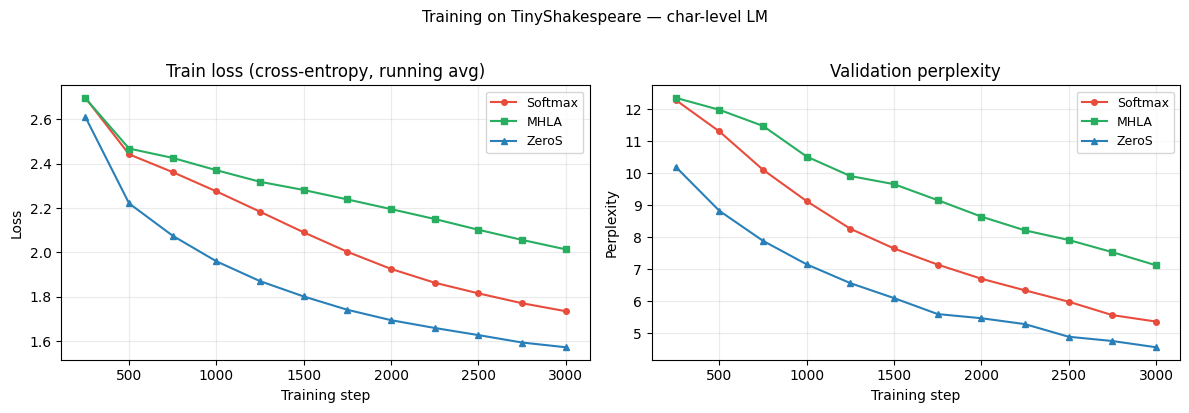

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Training on TinyShakespeare — char-level LM", fontsize=11, y=1.02)

for _name, _res in train_results.items():
    _kw = dict(color=COLORS[_name], marker=MARKS[_name],
               linewidth=1.5, markersize=4, label=_name)
    axes[0].plot(_res["steps"], _res["train"], **_kw)
    axes[1].plot(_res["steps"], [math.exp(v) for v in _res["val"]], **_kw)

axes[0].set_title("Train loss (cross-entropy, running avg)")
axes[0].set_ylabel("Loss")
axes[1].set_title("Validation perplexity")
axes[1].set_ylabel("Perplexity")
for ax in axes:
    ax.set_xlabel("Training step")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Summary

In [14]:
def full_val_ppl(model, max_batches=100):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for i, (xv, yv) in enumerate(val_loader):
            if i >= max_batches:
                break
            _, l = model(xv.to(device), yv.to(device))
            total += l.item()
            n     += 1
    return math.exp(total / n)

ppls   = {_n: full_val_ppl(_m) for _n, _m in models_trained.items()}
params = {_n: nparams(_m)      for _n, _m in models_trained.items()}

idx256 = SEQ_LENS.index(256)

print()
print(f"{'='*68}")
print(f"{'Model':<10} {'Params':>10} {'Val PPL':>9} {'fwd@L=256':>11} {'mem@L=256':>11}")
print(f"{'='*68}")
for _n in ("Softmax", "MHLA", "ZeroS"):
    _fms = f"{bench[_n]['fwd'][idx256]:.2f} ms"
    _mbs = f"{bench[_n]['mem'][idx256]:.1f} MB"
    print(f"{_n:<10} {params[_n]:>10,} {ppls[_n]:>9.2f} {_fms:>11} {_mbs:>11}")
print(f"{'='*68}")

print()
print(f"{'fwd+bwd latency (ms) vs L':}")
print(f"{'Model':<10}", end="")
for L in SEQ_LENS:
    print(f"  L={L:<5}", end="")
print()
print("-" * 68)
for _n in ("Softmax", "MHLA", "ZeroS"):
    print(f"{_n:<10}", end="")
    for t in bench[_n]["total"]:
        print(f"  {t:>7.2f}", end="")
    print()


Model          Params   Val PPL   fwd@L=256   mem@L=256
Softmax       842,752      5.49     0.71 ms     28.4 MB
MHLA          727,040      7.31     0.68 ms     28.5 MB
ZeroS         915,520      4.81     1.98 ms     71.9 MB

fwd+bwd latency (ms) vs L
Model       L=64     L=128    L=256    L=512    L=1024   L=2048 
--------------------------------------------------------------------
Softmax        1.87     2.18     2.28     1.55     4.34    13.93
MHLA           2.52     3.00     3.01     2.80     4.27    13.89
ZeroS          6.43     7.55     7.49     6.41     9.34    17.36


## Выводы

По полной валидации (100 батчей) после 3000 шагов:

| Модель | Параметры | Val PPL | fwd@L=256 | mem@L=256 |
|---|---|---|---|---|
| Softmax | 842,752 | 5.49 | 0.71 ms | 28.4 MB |
| MHLA | 727,040 | 7.31 | 0.68 ms | 28.5 MB |
| ZeroS | 915,520 | 4.81 | 1.98 ms | 71.9 MB |

ZeroS обошёл и Softmax, и MHLA по перплексии (4.81 против 5.49 и 7.31) и сходился быстрее всех на тренировке — похоже, отбрасывание нулевого (равномерно усредняющего) члена действительно помогает модели быстрее выделять полезные зависимости вместо траты ёмкости на их компенсацию. Платит за это памятью и скоростью: на L=256 он медленнее Softmax почти в 3 раза и использует в ~2.5 раза больше памяти, хотя с ростом длины последовательности (L=2048) разрыв в latency почти исчезает (17.4 мс против 13.9 мс).

MHLA при этом показал себя хуже Softmax по качеству (PPL 7.31 vs 5.49) при сопоставимой скорости и памяти — низкоранговая проекция (d_c = D/4) на такой небольшой модели, видимо, режет ёмкость сильнее, чем даёт выигрыш в KV-кэше, который на коротких последовательностях и так не критичен.

Итого: ZeroS — лучший вариант по качеству генерации ценой памяти и скорости на коротких последовательностях, MHLA на этом масштабе модели не оправдывает свою главную особенность (компактный KV-кэш), а Softmax остаётся надёжной серединой.
